## __Phase 3: Experiments__

### __Import packages__

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np

from scripts.experiments.experiment_01 import * 
from scripts.visualization.map_vessel_routes_v2 import * 

### __Preselection__

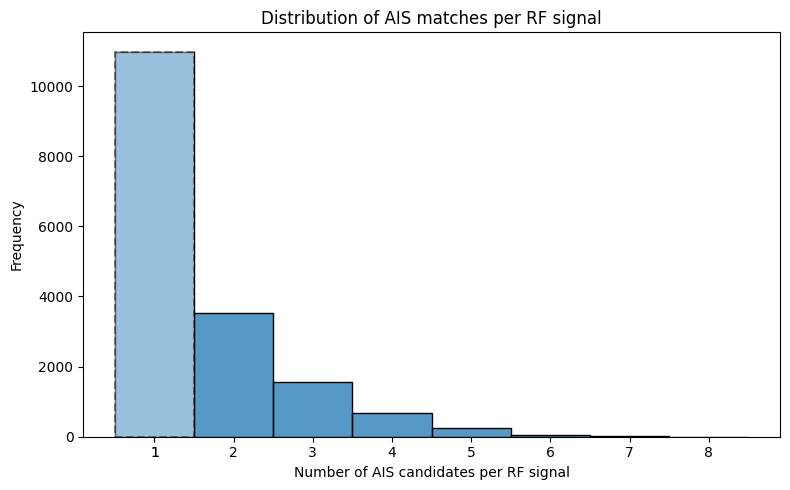

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

df_preselection = pd.read_pickle("/Users/kyrajongman/Documents/School/JADS/Thesis/RF_and_AIS/data/MSc_Thesis_24_25_KJ/AIS_RF_matching/scripts/test_scripts/AIS_RF_preselection_df_time_window_6km.pkl")

df_preselection_multimatch = df_preselection.groupby(['RF_track_id','RF_signal_id']).filter(lambda x: x['AIS_track_id'].count() > 1)
df_preselection_multimatch = df_preselection_multimatch.reset_index(drop=True)

# Compute counts per RF signal
counts = (
    df_preselection
    .groupby(['RF_track_id', 'RF_signal_id'])
    .size()
    .reset_index(name='count')
)


# Set bin width (e.g., 1)
binwidth = 1

# Plot histogram with seaborn
plt.figure(figsize=(8, 5))
ax = sns.histplot(counts['count'], binwidth=binwidth, edgecolor='black')

# Get the first patch (bar)
first_patch = ax.patches[0]
first_bin_left = first_patch.get_x()
first_bin_width = first_patch.get_width()
first_bar_height = first_patch.get_height()

# Draw transparent rectangle over the first bar
ax.add_patch(
    patches.Rectangle(
        (first_bin_left, 0),
        first_bin_width,
        first_bar_height,
        linewidth=1.5,
        edgecolor='black',
        linestyle='--',
        facecolor='white',
        alpha=0.4
    )
)

# Center xticks on bars
xtick_positions = [p.get_x() + p.get_width() / 2 for p in ax.patches]
xtick_labels = [int(p.get_x() + p.get_width() / 2) for p in ax.patches]
ax.set_xticks(xtick_positions)
ax.set_xticklabels(xtick_labels)

# Labels and title
plt.xlabel('Number of AIS candidates per RF signal')
plt.ylabel('Frequency')
plt.title('Distribution of AIS matches per RF signal')
plt.tight_layout()
plt.show()


In [83]:
print("Aantal unieke RF signalen in preselection:", df_preselection[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0]) # aantal unieke RF signalen in preselection
print("Aantal unieke RF signalen in preselection met meerdere AIS matches:", df_preselection[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0]-df_preselection_multimatch[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0])
print("Aantal unieke RF signalen in preselection met alleen hun eigen AIS match:", df_preselection_multimatch[['RF_signal_id', 'RF_track_id']].drop_duplicates().shape[0])
print("Percentage van RF signalen die eruit gefilterd worden:", round(((17081 - 6096)/17081)*100,2),' %') # percentage van RF signalen die matched zijn met AIS signalen
print("Percentage van RF signalen voor de rest van de resultaten worden:", 100 - round(((17081 - 6096)/17081)*100,2),' %')

Aantal unieke RF signalen in preselection: 17081
Aantal unieke RF signalen in preselection met meerdere AIS matches: 10985
Aantal unieke RF signalen in preselection met alleen hun eigen AIS match: 6096
Percentage van RF signalen die eruit gefilterd worden: 64.31  %
Percentage van RF signalen voor de rest van de resultaten worden: 35.69  %


### __Load forward results__

In [84]:
df_forward_results = pd.read_pickle("../scripts/test_scripts/forward_scores_new_preselection_df.pkl")

#### Results before filtering single matches

In [85]:
# To get below results -> PHMM needs to be runned

df_forward_results_prefilter = df_preselection.merge(
df_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results_prefilter.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 3)","(205717000, 3)",True,-15.656762,-0.041420,-0.074982,True
1,2,"(205717000, 3)","(205717000, 3)",True,-16.663595,-0.044084,-0.079804,True
2,3,"(205717000, 3)","(205717000, 3)",True,-15.896357,-0.042054,-0.076130,True
3,4,"(205717000, 3)","(205717000, 3)",True,-15.770054,-0.041720,-0.075525,True
4,1,"(205717000, 7)","(205717000, 7)",True,-11.115426,-0.055856,-0.094833,True


#### Results after filtering single matches (pure PHMM performance)

In [73]:
# To get below results -> PHMM needs to be runned
df_forward_results = pd.read_pickle("../scripts/test_scripts/forward_scores_new_preselection_df.pkl")
df_forward_results = df_preselection_multimatch.merge(
df_forward_results,    
    on=['RF_track_id', 'RF_signal_id','AIS_track_id'],
    how='inner',
    suffixes=('', '_y')
)
df_forward_results
df_forward_results.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(205717000, 82)","(477706700, 4)",False,-29.461525,-0.043010,-0.082629,False
2,1,"(209087000, 10)","(209087000, 10)",True,-29.016735,-0.032313,-0.063782,True
3,1,"(209087000, 10)","(311008600, 17)",False,-33.164059,-0.070412,-0.130301,False
4,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False


In [74]:
df_AIS = pd.read_pickle("../scripts/test_scripts/AIS_sample_no_RF_5000.pkl") 
df_AIS_stats = pd.read_pickle("../scripts/test_scripts/statistics_sample_5000.pkl")  
df_train_set = pd.read_pickle("../scripts/test_scripts/train_data_sample_5000.pkl") 

df_AIS_stats = df_AIS_stats.merge(df_AIS.groupby('ID')['distance_diff'].mean().reset_index(name='mean_intra_dist_diff'), on='ID', how='left')

df_AIS.head(5)

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
0,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:40:24,46.89339,-125.42151,13.7,93.0,NaN,NaN,NaN,3
1,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:44:15,46.89344,-125.39996,13.8,93.0,231.0,1.637508,25.519605,3
2,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:45:33,46.89350,-125.39274,13.9,94.0,78.0,0.548659,25.322724,3
3,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:46:39,46.89348,-125.38572,13.9,93.0,66.0,0.533426,29.095947,3
4,"(205717000, 3)",205717000,IMO9748485,2024-01-01 03:48:20,46.89355,-125.37695,13.9,93.0,101.0,0.666442,23.754352,3


### __Summary statistics of forward results__

In [34]:
# Calculate the average number of AIS tracks linked to each RF track 
AIS_tracks_per_RF_signal = df_forward_results.groupby(["RF_signal_id", "RF_track_id"])["AIS_track_id"].nunique()
average_AIS_matches_per_RF_signal = AIS_tracks_per_RF_signal.mean()
print(f"Average number of AIS tracks per RF track: {average_AIS_matches_per_RF_signal:.2f}")

Average number of AIS tracks per RF track: 2.65


In [35]:
#df_incorrect_chosen_stats
#plt.scatter(df_forward_results_v2['count'], df_forward_results_v2['normalized_forward_score_alpha'])

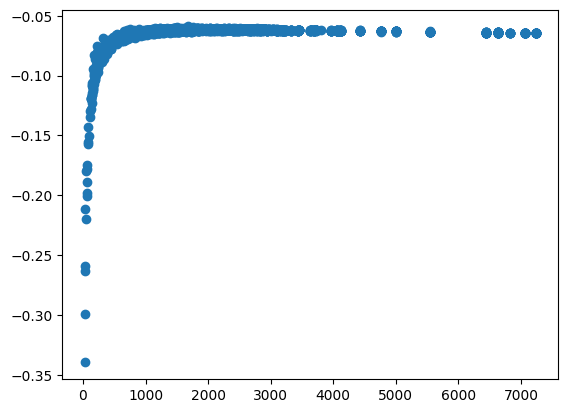

In [80]:
plt.scatter(df_correct_track_exp['#points'], df_correct_track_exp['normalized_forward_score_alpha'])

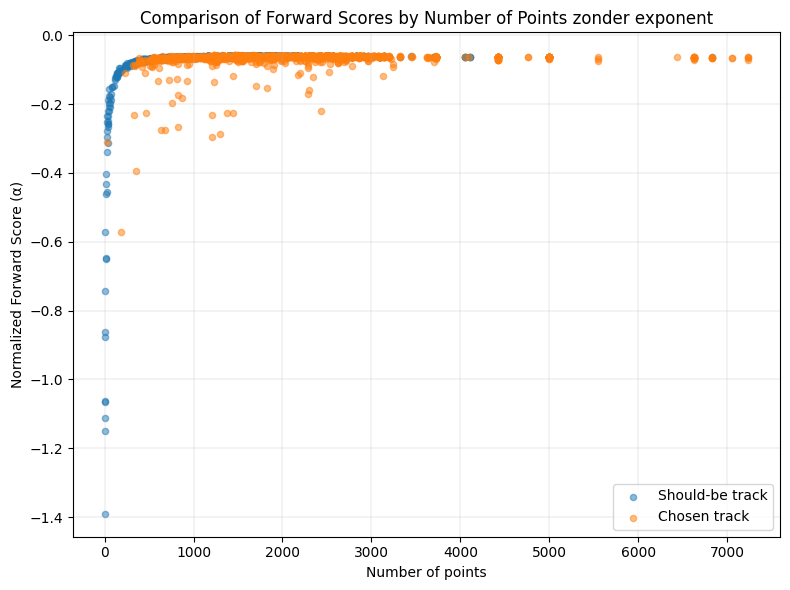

In [91]:
plt.figure(figsize=(8, 6))

# Eerste dataset (bijvoorbeeld: de juiste track die niet gekozen werd)
plt.scatter(
    df_incorrect_shouldbe_tracks['#points'], 
    df_incorrect_shouldbe_tracks['normalized_forward_score_alpha'], 
    label='Should-be track', 
    alpha=0.5,
    s=20
)

# Tweede dataset (bijvoorbeeld: de foutief gekozen track)
plt.scatter(
    df_incorrect_chosen_tracks['#points'], 
    df_incorrect_chosen_tracks['normalized_forward_score_alpha'], 
    label='Chosen track', 
    alpha=0.5,
    s=20
)

# Labels en legenda
plt.xlabel('Number of points')
plt.ylabel('Normalized Forward Score (α)')
plt.title('Comparison of Forward Scores by Number of Points zonder exponent')
plt.legend()
plt.grid(True, linewidth=0.2)
plt.tight_layout()
plt.show()


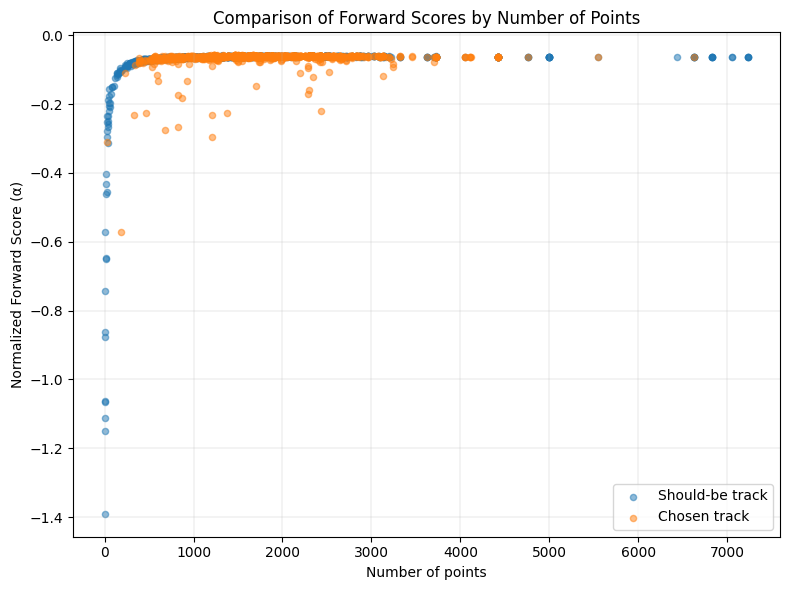

In [88]:
plt.figure(figsize=(8, 6))

# Eerste dataset (bijvoorbeeld: de juiste track die niet gekozen werd)
plt.scatter(
    df_incorrect_shouldbe_track_exp['#points'], 
    df_incorrect_shouldbe_track_exp['normalized_forward_score_alpha'], 
    label='Should-be track', 
    alpha=0.5,
    s=20
)

# Tweede dataset (bijvoorbeeld: de foutief gekozen track)
plt.scatter(
    df_incorrect_chosen_track_exp['#points'], 
    df_incorrect_chosen_track_exp['normalized_forward_score_alpha'], 
    label='Chosen track', 
    alpha=0.5,
    s=20
)

# Labels en legenda
plt.xlabel('Number of points')
plt.ylabel('Normalized Forward Score (α)')
plt.title('Comparison of Forward Scores by Number of Points')
plt.legend()
plt.grid(True, linewidth=0.2)
plt.tight_layout()
plt.show()


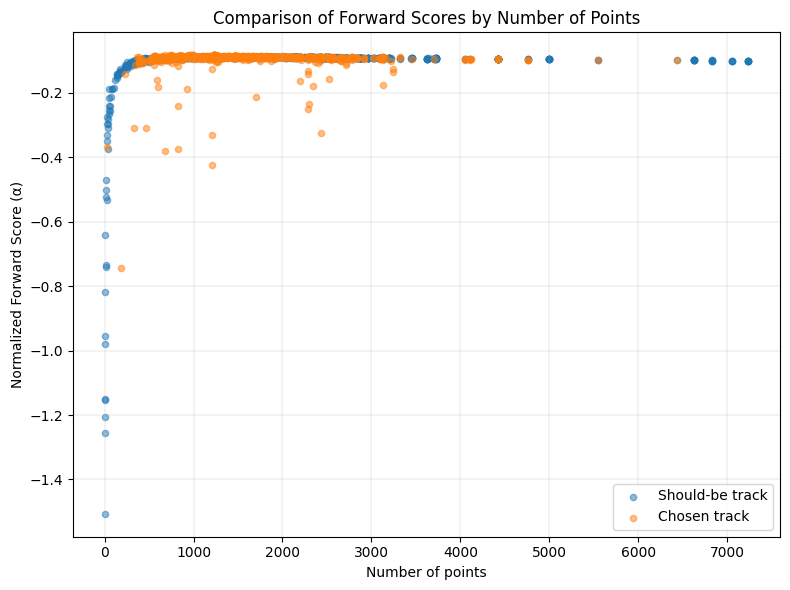

In [111]:
plt.figure(figsize=(8, 6))

# Eerste dataset (bijvoorbeeld: de juiste track die niet gekozen werd)
plt.scatter(
    df_incorrect_shouldbe_exp['count'], 
    df_incorrect_shouldbe_exp['normalized_forward_score_exp'], 
    label='Should-be track', 
    alpha=0.5,
    s=20
)

# Tweede dataset (bijvoorbeeld: de foutief gekozen track)
plt.scatter(
    df_incorrect_chosen_exp['count'], 
    df_incorrect_chosen_exp['normalized_forward_score_exp'], 
    label='Chosen track', 
    alpha=0.5,
    s=20
)

# Labels en legenda
plt.xlabel('Number of points')
plt.ylabel('Normalized Forward Score (α)')
plt.title('Comparison of Forward Scores by Number of Points')
plt.legend()
plt.grid(True, linewidth=0.2)
plt.tight_layout()
plt.show()


### __Results without exponent (0.9)__

In [58]:
def get_best_alignments(df, score_col):
    idx = df.groupby(['RF_signal_id', 'RF_track_id'])[score_col].idxmax().reset_index(drop=True)
    df['chosen'] = False
    df.loc[idx, 'chosen'] = True
    return df

In [64]:
df_with_chosen = get_best_alignments(df_forward_results, "normalized_forward_score")
df_with_chosen_alpha = get_best_alignments(df_forward_results, "normalized_forward_score_alpha")

In [62]:
def compute_confusion_counts(df_with_chosen):
    TP = ((df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FP = ((~df_with_chosen["is_true_match"]) & (df_with_chosen["chosen"])).sum()
    FN = ((df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    TN = ((~df_with_chosen["is_true_match"]) & (~df_with_chosen["chosen"])).sum()
    return TP, FP, FN, TN

def calculate_metrics(df_with_chosen):
    TP, FP, FN, TN = compute_confusion_counts(df_with_chosen)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy = (TP + TN) / (TP + FP + FN + TN)

    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "accuracy": round(accuracy, 4),
        "TP": int(TP),
        "FP": int(FP),
        "FN": int(FN),
        "TN": int(TN)
    }

metrics = calculate_metrics(df_with_chosen)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.6955
recall: 0.6955
f1_score: 0.6955
accuracy: 0.7702
TP: 4240
FP: 1856
FN: 1856
TN: 8199


In [65]:
metrics = calculate_metrics(df_with_chosen_alpha)
for key, value in metrics.items():
    print(f"{key}: {value}")

precision: 0.7782
recall: 0.7782
f1_score: 0.7782
accuracy: 0.8326
TP: 4744
FP: 1352
FN: 1352
TN: 8703


In [61]:
df_best_norm = df_with_chosen[df_with_chosen['chosen']==True].reset_index(drop=True)
df_best_norm

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,chosen
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False,True
2,2,"(209087000, 10)","(351567000, 19)",False,-34.065390,-0.031718,-0.063740,False,True
3,3,"(209087000, 10)","(351567000, 19)",False,-33.773565,-0.031447,-0.063194,False,True
4,4,"(209087000, 10)","(351567000, 19)",False,-34.266551,-0.031906,-0.064116,False,True
...,...,...,...,...,...,...,...,...,...
6091,2,"(671960000, 53)","(311000720, 3)",False,-65.373016,-0.027961,-0.060735,False,True
6092,1,"(671960000, 105)","(377911000, 150)",False,-52.202149,-0.035059,-0.072792,False,True
6093,2,"(671960000, 105)","(377911000, 150)",False,-50.899494,-0.034184,-0.070975,False,True
6094,3,"(671960000, 142)","(671960000, 142)",True,-35.427073,-0.031688,-0.063935,True,True


#### __Precision Score__

In [ ]:
def calculate_precision(df_best):
    TP = df_best["is_true_match"].sum()
    FP = (~df_best["is_true_match"]).sum()
    precision = TP / (TP + FP) 
    return (f"The precision score is: {precision:.4f}")

def calculate_recall(df_best):
    TP = df_best["is_true_match"].sum()
    # Elke punt heeft exact één ground-truth → dus TP + FN = totaal aantal punten
    FN = (~df_best["is_true_match"]).sum()
    recall = TP / (TP + FN)
    return f"The recall score is: {recall:.4f}"

def calculate_f1(df_best):
    TP = df_best["is_true_match"].sum()
    FP = (~df_best["is_true_match"]).sum()
    FN = FP  # want per punt is het of TP of FP+FN (zoals eerder besproken)
    
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1 = 2 * (precision * recall) / (precision + recall)
    return f"The F1 score is: {f1:.4f}"

def calculate_accuracy(df_best):
    TP = df_best["is_true_match"].sum()
    total = len(df_best)  # elk punt draagt 1 bij
    accuracy = TP / total
    return f"The accuracy score is: {accuracy:.4f}"


In [50]:
df_best_norm

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False
2,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True
3,1,"(209690000, 12)","(209690000, 12)",True,-51.843000,-0.028438,-0.060253,True
4,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True
...,...,...,...,...,...,...,...,...
6091,40,"(366904890, 0)","(366904890, 0)",True,-176.565999,-0.026643,-0.064228,True
6092,40,"(367121010, 0)","(367121010, 0)",True,-187.163029,-0.026522,-0.064337,True
6093,41,"(366904880, 0)","(367121010, 0)",False,-187.504843,-0.026570,-0.064455,False
6094,41,"(366904890, 0)","(366904890, 0)",True,-176.110035,-0.026575,-0.064062,True


In [14]:
df_best_norm["is_true_match"].sum(), (~df_best_norm["is_true_match"]).sum()


(np.int64(6653), np.int64(1700))

In [13]:
df_best_norm["is_true_match"].sum() + (~df_best_norm["is_true_match"]).sum()


np.int64(8353)

In [12]:
calculate_precision(df_best_norm)

'The precision score is: 0.7965'

In [13]:
# alles wat hierboven staat in een soort introductie zetten 

#### __Experiment 1__

##### Difference in distance and time between correct and incorrect (chosen) matches

In [14]:
def compute_time_dist_diff(df_best, df_train, suffix=""):
    # Make RF dataframe
    df_RF = df_train[df_train["RF"].notna()].copy()
    df_RF = df_RF[["ID", "RF_Timestamp", "RF"]]
    df_RF["RF_signal_id"] = df_RF.groupby("ID").cumcount() + 1

    # Merge RF with best alignments 
    df_merged = df_best.merge(df_RF.rename({"ID": "RF_track_id"}, axis=1), on=["RF_signal_id", "RF_track_id"], how="left")

    # Make AIS dataframe
    df_AIS = df_train[df_train["AIS"].notna()].copy()
    df_AIS_grouped = df_AIS.groupby("ID")
    
    if suffix != "":
        suffix = f"_{suffix}"

    # Function
    def compute_diffs(row):
        seq = df_AIS_grouped.get_group(row["AIS_track_id"])
        AIS_time, AIS_coords = min(
            zip(seq["AIS_Timestamp"], seq["AIS"]), 
            key=lambda x: abs(x[0] - row["RF_Timestamp"]).total_seconds())
            
        time_diff = abs((row["RF_Timestamp"] - AIS_time).total_seconds())
        distance_diff = haversine(row["RF"], AIS_coords)
            
        return pd.Series({
            f"AIS_Timestamp{suffix}": AIS_time,
            f"AIS{suffix}": AIS_coords,
            f"time_diff{suffix}": time_diff, 
            f"distance_diff{suffix}": distance_diff
            })
        
    cols = [
        f"AIS_Timestamp{suffix}", 
        f"AIS{suffix}", 
        f"time_diff{suffix}", 
        f"distance_diff{suffix}"
    ]
        
    df_merged[cols] = df_merged.apply(compute_diffs, axis=1)
    return df_merged

In [15]:
def boxplot_time_dist_diff(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots of time_diff and distance_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    time_correct = df_correct['time_diff']
    time_chosen = df_chosen['time_diff']
    dist_correct = df_correct['distance_diff']
    dist_chosen = df_chosen['distance_diff']

    data_time = [time_correct, time_chosen]
    data_dist = [dist_correct, dist_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        time_shouldbe = df_shouldbe['time_diff']
        dist_shouldbe = df_shouldbe['distance_diff']
        data_time.append(time_shouldbe)
        data_dist.append(dist_shouldbe)
        labels.append('Incorrect (should-be)')

    mean_time = [x.mean() for x in data_time]
    med_time = [x.median() for x in data_time]
    mean_dist = [x.mean() for x in data_dist]
    med_dist = [x.median() for x in data_dist]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    # Time difference boxplot
    ax1.boxplot(data_time, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title('Time difference (without outliers)')
    ax1.set_ylabel('Seconds')
    for i, (mean, median) in enumerate(zip(mean_time, med_time), start=1):
        ax1.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax1.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    # Distance difference boxplot
    ax2.boxplot(data_dist, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title('Distance difference (without outliers)')
    ax2.set_ylabel('Kilometers')
    
    for i, (mean, median) in enumerate(zip(mean_dist, med_dist), start=1):
        ax2.text(i + 0.17, mean, f"mean {mean:.1f}", color='green', ha='left', va='center')
        ax2.text(i - 0.17, median, f"median {median:.1f}", color='darkorange', ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [16]:
def histplot_time_dist_error(df_chosen, df_shouldbe):
    """
    Maakt histogrammen van de fout in tijd en afstand
    tussen incorrect gekozen match en de correcte (should-be).
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["time_error"] = df_merged["time_diff_chosen"] - df_merged["time_diff_shouldbe"]
    df_merged["distance_error"] = df_merged["distance_diff_chosen"] - df_merged["distance_diff_shouldbe"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Time error
    sns.histplot(df_merged["time_error"], bins=50, kde=True, ax=ax1)
    ax1.set_title("Histogram of time error (chosen − should-be)")
    ax1.set_xlabel("Tijd-fout (seconden)")
    ax1.set_ylabel("Frequentie")

    # Distance error
    sns.histplot(df_merged["distance_error"], bins=50, kde=True, ax=ax2)
    ax2.set_title("Histogram of distance error (chosen − should-be)")
    ax2.set_xlabel("Afstand-fout (kilometers)")
    ax2.set_ylabel("Frequentie")

    plt.tight_layout()
    plt.show()

In [17]:
df_best_norm

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False
2,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True
3,1,"(209444000, 0)","(209444000, 0)",True,-60.933221,-0.028500,-0.061355,True
4,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True
...,...,...,...,...,...,...,...,...
8348,40,"(366904890, 0)","(366904890, 0)",True,-176.565999,-0.026643,-0.064228,True
8349,41,"(366904880, 0)","(366904880, 0)",True,-172.648074,-0.026817,-0.064459,True
8350,41,"(366904890, 0)","(366904890, 0)",True,-176.110035,-0.026575,-0.064062,True
8351,41,"(366938780, 0)","(366938780, 0)",True,-192.876368,-0.026666,-0.064847,True


In [18]:
correct = df_best_norm[df_best_norm["is_true_match"]]
incorrect = df_best_norm[~df_best_norm["is_true_match"]]

df_correct = compute_time_dist_diff(correct, df_train_set)
df_incorrect_chosen = compute_time_dist_diff(incorrect, df_train_set)
df_incorrect_shouldbe_raw = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe = compute_time_dist_diff(df_incorrect_shouldbe_raw, df_train_set)

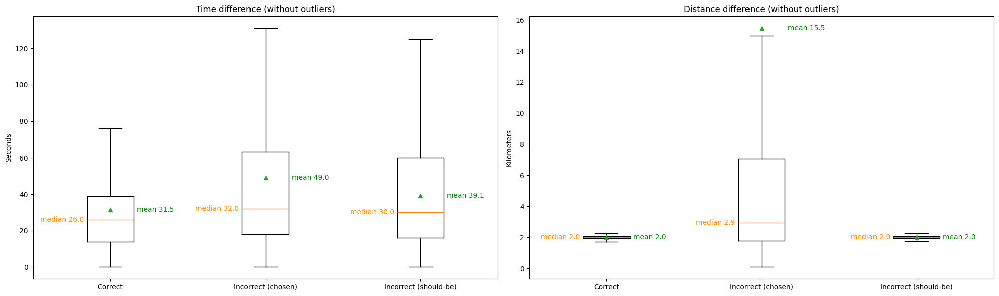

In [19]:
boxplot_time_dist_diff(df_correct, df_incorrect_chosen, df_incorrect_shouldbe)

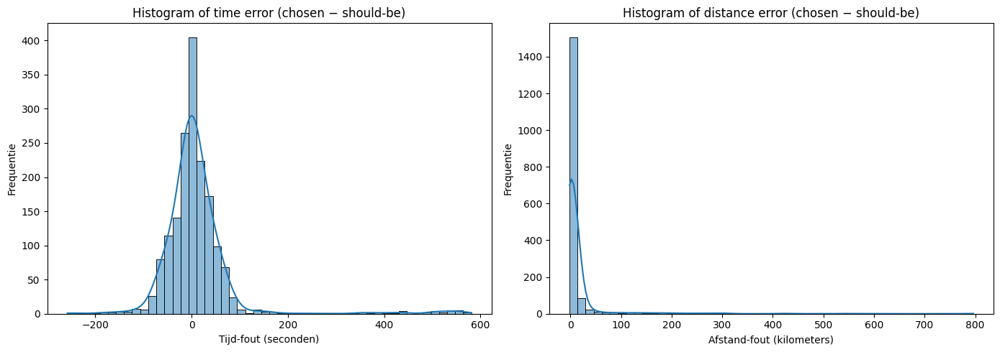

In [20]:
histplot_time_dist_error(df_incorrect_chosen, df_incorrect_shouldbe)

In [21]:
df_incorrect_chosen[df_incorrect_chosen['distance_diff'] == df_incorrect_chosen['distance_diff'].max()]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
1572,15,"(367050160, 2)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,798.273469


In [22]:
AIS_filtered = df_AIS[df_AIS["ID"].isin([(316014160, 1), (367050160, 2)])]
RF_filtered = df_train_set[(df_train_set["ID"]== (367050160, 2)) & (~df_train_set["RF"].isna())].iloc[14]

In [23]:
RF_filtered

ID                                         (367050160, 2)
track_id                                                2
MMSI                                            367050160
Timestamp                             2024-01-06 11:40:10
AIS_Timestamp                                         NaT
RF_Timestamp                          2024-01-06 11:40:10
AIS                                                  None
RF               [42.963988541126064, -82.43202881084191]
State                                                  RF
Name: 1014680, dtype: object

In [24]:
# Initialize the interactive map
map_center = [AIS_filtered["LAT"].mean(), AIS_filtered["LON"].mean()]
map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")

# Kleuren per SubTrackID
unique_ids = AIS_filtered["track_id"].unique()
colors = ["#e14a5b", "#117b88", "#9dc6ce", "#f46d43", "#fee08b"]
color_map = {track_id: colors[i % len(colors)] for i, track_id in enumerate(unique_ids)}

# Plot AIS route
ais_layer = folium.FeatureGroup(name="AIS Tracks")
for (mmsi, track_id), group in AIS_filtered.groupby("ID"):
    color = color_map[track_id]
    for _, row in group.iterrows():
        heading = 315 + row['Heading']
        icon_html = f'''
            <div style="font-size:12px; transform: rotate({heading}deg);">
                <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
            </div>
            '''
        folium.Marker(
            location=(row['LAT'], row['LON']),
            tooltip=f"AIS Point\nMMSI: {mmsi}\nTrack: {track_id}\nTime: {row['BaseDateTime']}",
            icon=folium.DivIcon(html=icon_html)
        ).add_to(ais_layer)
ais_layer.add_to(map)

# Plot RF signals
rf_layer = folium.FeatureGroup(name="RF Signals")
track_id = RF_filtered["track_id"]
color = "blue"
icon_html = f'''
    <i class="fa-solid fa-star" style="color: {color};"></i>
    '''
folium.Marker(
    location=RF_filtered["RF"],
    tooltip=f"RF signal: {RF_filtered['RF_Timestamp']}",
    icon=folium.DivIcon(html=icon_html),
).add_to(rf_layer)
rf_layer.add_to(map)

folium.LayerControl(collapsed=False).add_to(map)
map

In [25]:
df_train_set[df_train_set["ID"].isin([(316014160, 1)]) & (~df_train_set["AIS"].isna())]

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
627873,"(316014160, 1)",1,316014160,2024-01-04 05:47:58,2024-01-04 05:47:58,NaT,"[42.34838, -82.94594]",None,AIS
627874,"(316014160, 1)",1,316014160,2024-01-04 05:52:57,2024-01-04 05:52:57,NaT,"[42.35479, -82.93072]",None,AIS
627875,"(316014160, 1)",1,316014160,2024-01-04 05:58:17,2024-01-04 05:58:17,NaT,"[42.36042, -82.91266]",None,AIS
627876,"(316014160, 1)",1,316014160,2024-01-04 05:59:26,2024-01-04 05:59:26,NaT,"[42.36167, -82.90867]",None,AIS
627877,"(316014160, 1)",1,316014160,2024-01-04 06:00:07,2024-01-04 06:00:07,NaT,"[42.36243, -82.90628]",None,AIS
...,...,...,...,...,...,...,...,...,...
630648,"(316014160, 1)",1,316014160,2024-01-06 11:23:46,2024-01-06 11:23:46,NaT,"[48.35366, -89.22828]",None,AIS
630649,"(316014160, 1)",1,316014160,2024-01-06 11:24:47,2024-01-06 11:24:47,NaT,"[48.35378, -89.22857]",None,AIS
630650,"(316014160, 1)",1,316014160,2024-01-06 11:26:26,2024-01-06 11:26:26,NaT,"[48.35388, -89.2289]",None,AIS
630651,"(316014160, 1)",1,316014160,2024-01-06 11:28:37,2024-01-06 11:28:37,NaT,"[48.35392, -89.22914]",None,AIS


In [26]:
df_preselection[(df_preselection["RF_signal_id"] == 15) & (df_preselection["RF_track_id"] == (367050160, 2))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match
20925,15,"(367050160, 2)","(316001701, 19)",False
20926,15,"(367050160, 2)","(316004910, 34)",False
20927,15,"(367050160, 2)","(316014160, 1)",False
20928,15,"(367050160, 2)","(316052496, 0)",False
20929,15,"(367050160, 2)","(366893910, 3)",False
20930,15,"(367050160, 2)","(366904890, 0)",False
20931,15,"(367050160, 2)","(366904910, 1)",False
20932,15,"(367050160, 2)","(366904930, 2)",False
20933,15,"(367050160, 2)","(366906610, 2)",False
20934,15,"(367050160, 2)","(366938770, 0)",False


In [27]:
df_AIS[df_AIS['ID']==(367050160, 2)]

,ID,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading,time_diff,distance_diff,speed_kph,track_id
1941694,"(367050160, 2)",367050160,IMO7514713,2024-01-04 10:48:15,41.49649,-81.72381,0.0,511.0,NaN,NaN,NaN,2
1941695,"(367050160, 2)",367050160,IMO7514713,2024-01-04 10:52:03,41.49647,-81.72380,0.0,511.0,228.0,0.002375,0.037496,2
1941696,"(367050160, 2)",367050160,IMO7514713,2024-01-04 10:53:14,41.49647,-81.72383,0.0,511.0,71.0,0.002499,0.126687,2
1941697,"(367050160, 2)",367050160,IMO7514713,2024-01-04 10:54:45,41.49647,-81.72386,0.0,511.0,91.0,0.002499,0.098843,2
1941698,"(367050160, 2)",367050160,IMO7514713,2024-01-04 10:57:54,41.49645,-81.72381,0.0,511.0,189.0,0.004721,0.089921,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1944366,"(367050160, 2)",367050160,IMO7514713,2024-01-06 19:54:35,44.51358,-82.31987,12.6,352.0,69.0,0.448148,23.381631,2
1944367,"(367050160, 2)",367050160,IMO7514713,2024-01-06 19:55:47,44.51769,-82.32075,12.6,352.0,72.0,0.462307,23.115373,2
1944368,"(367050160, 2)",367050160,IMO7514713,2024-01-06 19:57:06,44.52232,-82.32176,12.6,352.0,79.0,0.521023,23.742837,2
1944369,"(367050160, 2)",367050160,IMO7514713,2024-01-06 19:58:16,44.52641,-82.32267,12.6,352.0,70.0,0.460474,23.681529,2


In [28]:
df_incorrect_chosen_stats[(df_incorrect_chosen_stats["RF_signal_id"] == 15) & (df_incorrect_chosen_stats["RF_track_id"] == (367050160, 2))]

NameError: name 'df_incorrect_chosen_stats' is not defined

In [ ]:
df_incorrect_chosen[(df_incorrect_chosen["RF_signal_id"] == 15) & (df_incorrect_chosen["RF_track_id"] == (367050160, 2))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
1572,15,"(367050160, 2)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,798.273469


In [ ]:
df_incorrect_chosen_tracks[(df_incorrect_chosen_tracks["RF_signal_id"] == 15) & (df_incorrect_chosen_tracks["RF_track_id"] == (367050160, 2))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,#points
1572,15,"(367050160, 2)","(316014160, 1)",False,-0.027147,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,798.273469,"(316014160, 1)",2780


In [ ]:
df_incorrect_shouldbe_stats[(df_incorrect_shouldbe_stats["RF_signal_id"] == 15) & (df_incorrect_shouldbe_stats["RF_track_id"] == (367050160, 2))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,...,ID_x,mean_intra_time_diff,ID_y,mean_intra_dist_diff_x,ID,mean_intra_dist_diff_y,ID_y,mean_intra_dist_diff,ID_y,mean_intra_dist_diff_y
750,15,"(367050160, 2)","(367050160, 2)",True,-74.751815,-0.027924,-0.061481,True,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",...,"(367050160, 2)",76.932362,"(367050160, 2)",0.181477,"(367050160, 2)",0.181477,"(367050160, 2)",0.181477,"(367050160, 2)",0.181477


In [ ]:
df_incorrect_shouldbe_tracks[(df_incorrect_shouldbe_tracks["RF_signal_id"] == 15) & (df_incorrect_shouldbe_tracks["RF_track_id"] == (367050160, 2))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,#points
750,15,"(367050160, 2)","(367050160, 2)",True,-74.751815,-0.027924,-0.061481,True,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",2024-01-06 11:40:16,"[42.94696, -82.43474]",6.0,1.906302,"(367050160, 2)",2677


In [ ]:
df_incorrect_chosen[(df_incorrect_chosen["AIS_track_id"] == (316014160, 1))]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
263,2,"(316004910, 34)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[42.95213830337236, -82.46171559511171]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,797.781141
1572,15,"(367050160, 2)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[42.963988541126064, -82.43202881084191]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,798.273469
1603,16,"(366904910, 1)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[46.50633614317148, -84.3794971752487]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,418.562587
1679,20,"(316001701, 19)","(316014160, 1)",False,-75.468964,-0.027147,-0.059997,False,2024-01-06 11:40:10,"[46.466149593059804, -84.27442250986205]",2024-01-06 11:32:50,"[48.35395, -89.22919]",440.0,427.758660


In [ ]:
df_incorrect_chosen[(df_incorrect_chosen["time_diff"] >120) | (df_incorrect_chosen["distance_diff"] > 2)]["time_diff"].mean()

np.float64(52.47866108786611)

In [ ]:
df_incorrect_chosen[(df_incorrect_chosen["time_diff"] <=120) & (df_incorrect_chosen["distance_diff"] <= 2)]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff
2,1,"(215228000, 7)","(636017316, 12)",False,-36.088777,-0.030819,-0.062470,False,2024-01-07 23:08:37,"[29.914754047068236, -89.92648390302227]",2024-01-07 23:09:31,"[29.92402, -89.93593]",54.0,1.374904
6,1,"(235110737, 5)","(636014220, 3)",False,-83.856082,-0.027648,-0.061638,False,2024-01-07 23:08:37,"[32.13415334961047, -81.14429735503863]",2024-01-07 23:07:16,"[32.1393, -81.14318]",81.0,0.581872
8,1,"(244109000, 3)","(477287000, 23)",False,-47.652462,-0.029163,-0.061117,False,2024-01-04 11:40:10,"[30.72305355369483, -88.04457621872623]",2024-01-04 11:39:06,"[30.72098, -88.0426]",64.0,0.298073
21,1,"(249558000, 60)","(636015819, 55)",False,-30.908556,-0.031799,-0.063267,False,2024-01-17 23:08:37,"[39.258712514195196, -76.56317593125274]",2024-01-17 23:07:12,"[39.24135, -76.5658]",85.0,1.943804
28,1,"(257408000, 33)","(311000808, 26)",False,-41.715439,-0.030011,-0.061885,False,2024-01-19 08:26:02,"[39.250024060483824, -76.55656476286785]",2024-01-19 08:27:17,"[39.26032, -76.55434]",75.0,1.160773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1686,21,"(256524000, 97)","(636022464, 30)",False,-67.974143,-0.028112,-0.061268,False,2024-01-26 05:08:47,"[38.964993710581815, -76.41568441956093]",2024-01-26 05:08:50,"[38.96382, -76.40593]",3.0,0.853389
1690,21,"(373874000, 14)","(352508000, 46)",False,-68.029788,-0.027927,-0.060910,False,2024-01-21 19:11:03,"[30.07064678265957, -90.88648909804203]",2024-01-21 19:10:35,"[30.06457, -90.87482]",28.0,1.310565
1696,22,"(636018910, 0)","(373765000, 12)",False,-75.801942,-0.028064,-0.061846,False,2024-01-04 02:07:00,"[29.96965953769862, -90.28108684063935]",2024-01-04 02:07:19,"[29.95919, -90.29781]",19.0,1.987593
1697,23,"(636022464, 30)","(256524000, 97)",False,-70.208690,-0.027938,-0.061125,False,2024-01-26 11:40:10,"[38.950778343375596, -76.41469813659661]",2024-01-26 11:39:07,"[38.95074, -76.41838]",63.0,0.318417


In [ ]:
# om te achterhalen hoe het model fout gaat, kijken we eerst naar de karakteristieken van de RF punten en hun dichtsbijzinde AIS punt
#Errors in tijd lijken redelijk normaal verdeeld maar wel een kleine piek rond de 500 sec. dus daar lijkt weinig echt aan de hand. 
# Distance errors zijn scheef verdeeld maar dat komt ook omdat we gegenereed hebben om mean 2km. Wel opvallend te noemen dat er een match is op 800km

Conclusie: 

Time difference error: 

- De overgrote meerderheid zit binnen +- 2 minuten tussen gekozen en juiste match
- Er zijn enkele uitschieters waarbij de gekozen match veel later valt dan de juiste match

Distance difference error: 

- In bijna alle gevallen ligt de gekozen match qua afstand verder weg dan de juiste
- In een klein aantal gevallen wijken de gekozen en juiste match extreem af (niet perse erg toch?)

#### __Experiment 2__

In [29]:
def compute_mean_intra_time(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "mean_intra_time_diff"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [30]:
def boxplot_mean_intra_time(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of mean_intra_time_diff for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct['mean_intra_time_diff']
    intra_chosen  = df_chosen['mean_intra_time_diff']

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe['mean_intra_time_diff']
        data.append(intra_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Mean intra-time difference: Correct vs Incorrect')
    ax.set_ylabel('Seconds')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [31]:
def histplot_intra_time_error(df_chosen, df_shouldbe):
    """
    Plots a histogram of the error in mean intra-time between
    incorrectly chosen and should-be AIS tracks.
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["intra_time_error"] = (df_merged["mean_intra_time_diff_chosen"] - df_merged["mean_intra_time_diff_shouldbe"])

    plt.figure(figsize=(8, 6))
    sns.histplot(df_merged["intra_time_error"], bins=50, kde=True)
    plt.title("Histogram of mean intra-time error (chosen − should-be)")
    plt.xlabel("Mean intra-time error (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [32]:
df_correct_stats = compute_mean_intra_time(df_correct, df_AIS_stats)
df_incorrect_chosen_stats = compute_mean_intra_time(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_mean_intra_time(df_incorrect_shouldbe, df_AIS_stats)

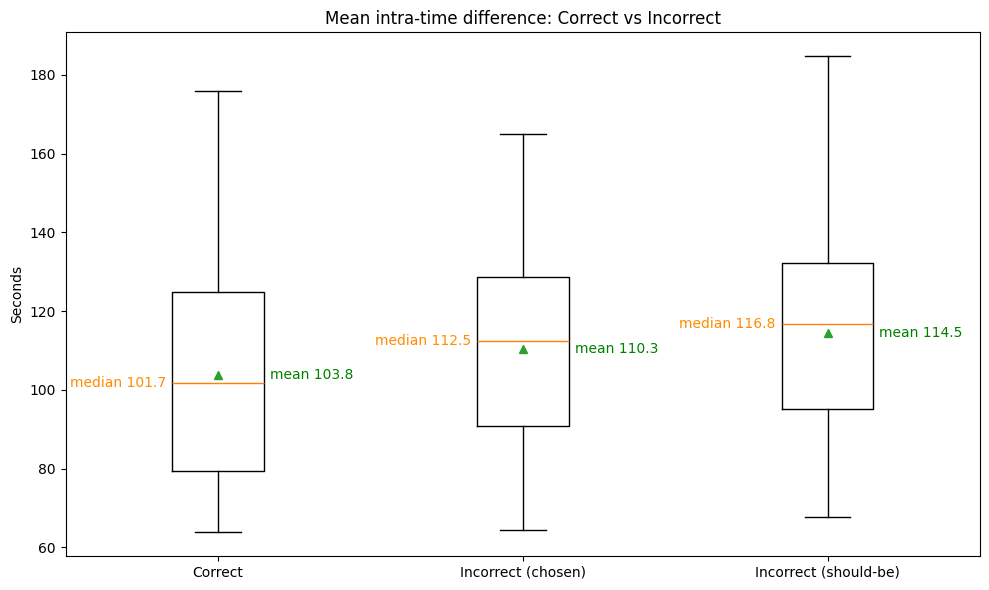

In [33]:
boxplot_mean_intra_time(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

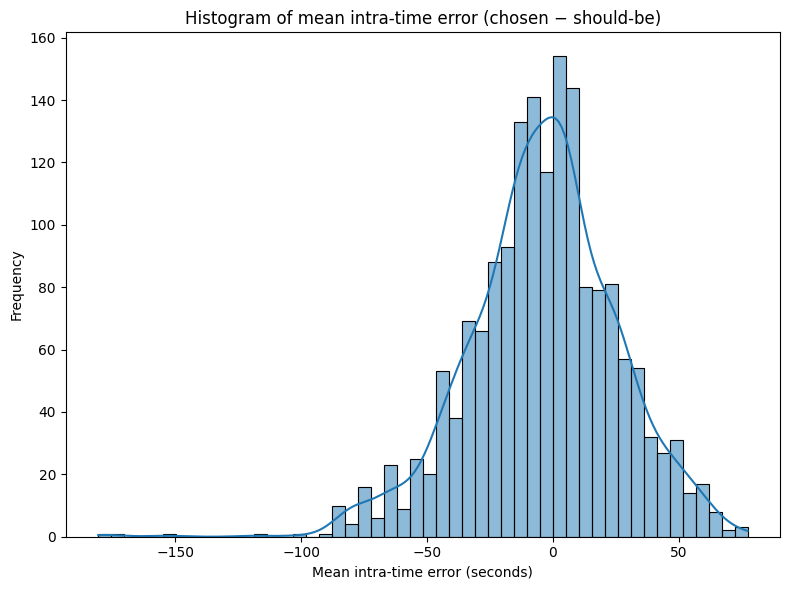

In [34]:
histplot_intra_time_error(df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

Conclusie:

De gekozen AIS track heeft een lagere gemiddelde intra-time dan de juiste (verdeling is scheef naar links). 

In [35]:
def compute_mean_intra_dist(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "mean_intra_dist_diff"]], left_on = "AIS_track_id", right_on = "ID", how = "left", suffixes=("", "_y"))

In [36]:
def boxplot_mean_intra_dist(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of compute_mean_intra_dist for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    intra_correct = df_correct['mean_intra_dist_diff']
    intra_chosen  = df_chosen['mean_intra_dist_diff']

    data = [intra_correct, intra_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        intra_shouldbe = df_shouldbe['mean_intra_dist_diff']
        data.append(intra_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=True, showmeans=True)
    ax.set_title('Mean intra-distance difference: Correct vs Incorrect')
    ax.set_ylabel('Kilometers')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.3f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.3f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [37]:
df_correct_stats = compute_mean_intra_dist(df_correct_stats, df_AIS_stats)
df_incorrect_chosen_stats = compute_mean_intra_dist(df_incorrect_chosen_stats, df_AIS_stats)
df_incorrect_shouldbe_stats = compute_mean_intra_dist(df_incorrect_shouldbe_stats, df_AIS_stats)

In [38]:
df_correct_stats

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,mean_intra_time_diff,ID_y,mean_intra_dist_diff
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True,2024-01-07 19:11:03,"[46.905318377563226, -124.17452001867974]",2024-01-07 19:10:53,"[46.90912, -124.14942]",10.0,1.953055,"(205717000, 82)",77.755682,"(205717000, 82)",0.384490
1,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True,2024-01-11 05:08:47,"[29.898886093035756, -90.1250250694274]",2024-01-11 05:08:11,"[29.91144, -90.11216]",36.0,1.867184,"(209087000, 15)",71.691223,"(209087000, 15)",0.396757
2,1,"(209444000, 0)","(209444000, 0)",True,-60.933221,-0.028500,-0.061355,True,2024-01-01 02:07:00,"[35.28359781508663, -75.04250200482615]",2024-01-01 02:07:09,"[35.26637, -75.0401]",9.0,1.928018,"(209444000, 0)",93.484324,"(209444000, 0)",0.298297
3,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True,2024-01-19 23:08:37,"[29.952103292283702, -90.1296616728874]",2024-01-19 23:09:06,"[29.9368, -90.14206]",29.0,2.079106,"(209690000, 25)",145.886445,"(209690000, 25)",0.168950
4,1,"(210025000, 15)","(210025000, 15)",True,-54.813382,-0.028698,-0.061088,True,2024-01-07 19:11:03,"[28.25235409606757, -89.09313620222215]",2024-01-07 19:11:24,"[28.23739, -89.07822]",21.0,2.214397,"(210025000, 15)",142.226820,"(210025000, 15)",0.159100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6648,40,"(366904890, 0)","(366904890, 0)",True,-176.565999,-0.026643,-0.064228,True,2024-01-06 15:27:16,"[43.622591049763614, -82.44305256476511]",2024-01-06 15:27:05,"[43.64124, -82.44533]",11.0,2.081756,"(366904890, 0)",76.059463,"(366904890, 0)",0.342379
6649,41,"(366904880, 0)","(366904880, 0)",True,-172.648074,-0.026817,-0.064459,True,2024-01-06 19:11:03,"[46.74284326350594, -92.1033090578235]",2024-01-06 19:10:28,"[46.75925, -92.09725]",35.0,1.881846,"(366904880, 0)",78.293926,"(366904880, 0)",0.366037
6650,41,"(366904890, 0)","(366904890, 0)",True,-176.110035,-0.026575,-0.064062,True,2024-01-06 19:11:03,"[42.956512484772496, -82.44321973495126]",2024-01-06 19:11:05,"[42.9639, -82.4197]",2.0,2.082769,"(366904890, 0)",76.059463,"(366904890, 0)",0.342379
6651,41,"(366938780, 0)","(366938780, 0)",True,-192.876368,-0.026666,-0.064847,True,2024-01-06 19:11:03,"[42.81587749067469, -78.91416516853664]",2024-01-06 19:11:34,"[42.83168, -78.91591]",31.0,1.762914,"(366938780, 0)",69.689021,"(366938780, 0)",0.297515


In [87]:
boxplot_mean_intra_dist(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

NameError: name 'boxplot_mean_intra_dist' is not defined

#### __Experiment 3__

In [40]:
def compute_track_behavior(df, df_AIS, stationary_threshold = 5):
    """
    Adds per-track behavior statistics to the given dataframe
    """
    df_AIS = df_AIS.copy()
    df_AIS["is_stationary"] = df_AIS["speed_kph"] < stationary_threshold
    track_behavior_stats = (
        df_AIS
        .groupby("ID")
        .agg(
            std_speed_kph = ("speed_kph", "std"),
            stationary_ratio = ("is_stationary", "mean")
        )
        .reset_index()
        .set_index("ID")
    )
    return df.merge(track_behavior_stats, left_on = "AIS_track_id", right_on = "ID", how = "left")

In [41]:
def boxplot_track_behavior(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates boxplots for track-level behavior metrics:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    speed_correct = df_correct['std_speed_kph']
    speed_chosen  = df_chosen['std_speed_kph']
    station_correct = df_correct['stationary_ratio']
    station_chosen  = df_chosen['stationary_ratio']

    speed_data = [speed_correct, speed_chosen]
    stationary_data = [station_correct, station_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        speed_shouldbe = df_shouldbe['std_speed_kph']
        station_shouldbe = df_shouldbe['stationary_ratio']
        speed_data.append(speed_shouldbe)
        stationary_data.append(station_shouldbe)
        labels.append('Incorrect (should-be)')

    speed_means = [x.mean() for x in speed_data]
    speed_medians = [x.median() for x in speed_data]
    station_means = [x.mean() for x in stationary_data]
    station_medians = [x.median() for x in stationary_data]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

    ax1.boxplot(speed_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax1.set_title("Speed Variation (std_speed_kph)")
    ax1.set_ylabel("Standard Deviation of Speed (km/h)")

    for i, (m, med) in enumerate(zip(speed_means, speed_medians), start=1):
        ax1.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax1.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    ax2.boxplot(stationary_data, tick_labels=labels, showfliers=False, showmeans=True)
    ax2.set_title("Stationary Behavior (stationary_ratio)")
    ax2.set_ylabel("Proportion of Time Stationary (< 5 km/h)")

    for i, (m, med) in enumerate(zip(station_means, station_medians), start=1):
        ax2.text(i + 0.17, m,   f"mean {m:.2f}", color="green", ha='left', va='center')
        ax2.text(i - 0.17, med, f"median {med:.2f}", color="darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()


In [42]:
def histplot_track_behavior_errors(df_chosen, df_shouldbe):
    """
    Plots histograms of the errors between incorrectly chosen and should-be AIS tracks
    for:
    - std_speed_kph (speed variability)
    - stationary_ratio (proportion of time under threshold)
    """
    df_merged = df_chosen.merge(
        df_shouldbe,
        on=["RF_signal_id", "RF_track_id"],
        suffixes=('_chosen', '_shouldbe'),
        how="inner"
    )

    df_merged["speed_std_error"] = (df_merged["std_speed_kph_chosen"] - df_merged["std_speed_kph_shouldbe"])
    df_merged["stationary_error"] = (df_merged["stationary_ratio_chosen"] - df_merged["stationary_ratio_shouldbe"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df_merged["speed_std_error"], bins=50, kde=True, ax=axes[0])
    axes[0].set_title("Speed std error (chosen − should-be)")
    axes[0].set_xlabel("Speed std error (km/h)")
    axes[0].set_ylabel("Frequency")

    sns.histplot(df_merged["stationary_error"], bins=50, kde=True, ax=axes[1])
    axes[1].set_title("Stationary ratio error (chosen − should-be)")
    axes[1].set_xlabel("Stationary ratio error")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


In [43]:
df_correct_behavior = compute_track_behavior(df_correct, df_AIS)
df_incorrect_chosen_behavior = compute_track_behavior(df_incorrect_chosen, df_AIS)
df_incorrect_shouldbe_behavior = compute_track_behavior(df_incorrect_shouldbe, df_AIS)

In [86]:
boxplot_track_behavior(df_correct_behavior, df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

NameError: name 'boxplot_track_behavior' is not defined

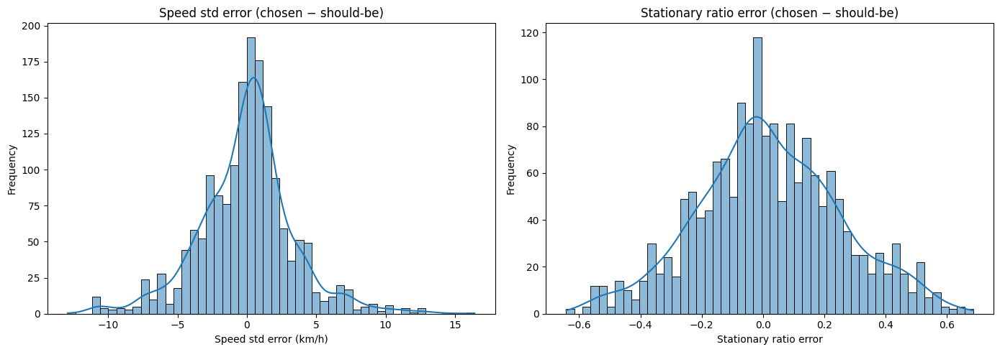

In [45]:
histplot_track_behavior_errors(df_incorrect_chosen_behavior, df_incorrect_shouldbe_behavior)

#### __Experiment 4__

In [46]:
def compute_track_length(df, df_AIS_stats):
    """
    Adds 'mean_intra_time_diff' column to a dataframe
    """
    return df.merge(df_AIS_stats[["ID", "#points"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [47]:
def boxplot_track_length(df_correct, df_chosen, df_shouldbe=None):
    """
    Creates a boxplot of track_length for:
    - Correct matches
    - Incorrect (chosen)
    - Optional: Incorrect (should-be)
    """
    length_correct = df_correct['#points']
    length_chosen  = df_chosen['#points']

    data = [length_correct, length_chosen]
    labels = ['Correct', 'Incorrect (chosen)']

    if df_shouldbe is not None:
        length_shouldbe = df_shouldbe['#points']
        data.append(length_shouldbe)
        labels.append('Incorrect (should-be)')

    means = [x.mean() for x in data]
    medians = [x.median() for x in data]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
    ax.set_title('Number of AIS points per track: Correct vs Incorrect')
    ax.set_ylabel('Number of points')

    for i, (mean, median) in enumerate(zip(means, medians), start=1):
        ax.text(i + 0.17, mean, f"mean {mean:.1f}", color = "green", ha='left', va='center')
        ax.text(i - 0.17, median, f"median {median:.1f}", color = "darkorange", ha='right', va='center')

    plt.tight_layout()
    plt.show()

In [48]:
df_correct_tracks = compute_track_length(df_correct, df_AIS_stats)
df_incorrect_chosen_tracks = compute_track_length(df_incorrect_chosen, df_AIS_stats)
df_incorrect_shouldbe_tracks = compute_track_length(df_incorrect_shouldbe, df_AIS_stats)

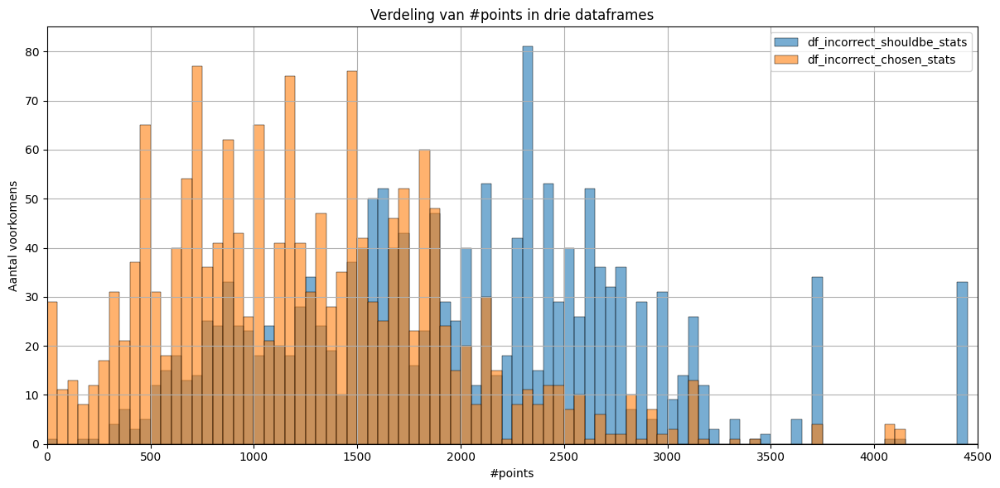

In [49]:
bins = range(0, 9100, 50) 

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_chosen_tracks['#points'], bins=bins, alpha=0.6, label='df_incorrect_shouldbe_stats')
sns.histplot(df_incorrect_shouldbe_tracks['#points'], bins=bins, alpha=0.6, label='df_incorrect_chosen_stats')

plt.xlabel('#points')
plt.ylabel('Aantal voorkomens')
plt.title('Verdeling van #points in drie dataframes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


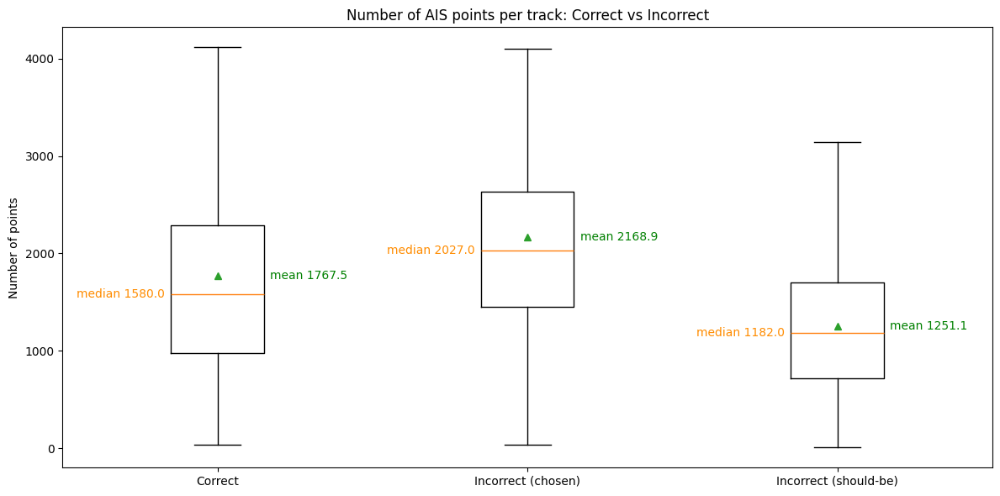

In [50]:
boxplot_track_length(df_correct_tracks, df_incorrect_chosen_tracks, df_incorrect_shouldbe_tracks)

In [51]:
# def compute_sampling_rate(df, df_AIS_stats):
#     """
#     Adds 'mean_intra_time_diff' column to a dataframe
#     """
#     df_AIS_stats = df_AIS_stats.copy()
#     df_AIS_stats["sampling_rate"] = df_AIS_stats["#points"]/df_AIS_stats["track_duration"]
#     return df.merge(df_AIS_stats[["ID", "sampling_rate"]], left_on = "AIS_track_id", right_on = "ID", how = "left")

In [52]:
# def boxplot_sampling_rate(df_correct, df_chosen, df_shouldbe=None):
#     """
#     Creates a boxplot of the sampling rate (AIS points per track) for:
#     - Correct matches
#     - Incorrect (chosen)
#     - Optional: Incorrect (should-be)
#     """
#     rate_correct = df_correct['sampling_rate']
#     rate_chosen = df_chosen['sampling_rate']

#     data = [rate_correct, rate_chosen]
#     labels = ['Correct', 'Incorrect (chosen)']

#     if df_shouldbe is not None:
#         rate_shouldbe = df_shouldbe['sampling_rate']
#         data.append(rate_shouldbe)
#         labels.append('Incorrect (should-be)')

#     means = [x.mean() for x in data]
#     medians = [x.median() for x in data]

#     fig, ax = plt.subplots(figsize=(12, 6))
#     ax.boxplot(data, tick_labels=labels, showfliers=False, showmeans=True)
#     ax.set_title('Sampling Rate: Correct vs Incorrect Matches')
#     ax.set_ylabel('AIS points per unit time (sampling rate)')

#     for i, (mean, median) in enumerate(zip(means, medians), start=1):
#         ax.text(i + 0.17, mean, f"mean {mean:.2f}", color="green", ha='left', va='center')
#         ax.text(i - 0.17, median, f"median {median:.2f}", color="darkorange", ha='right', va='center')

#     plt.tight_layout()
#     plt.show()

In [53]:
# df_correct_stats = compute_sampling_rate(df_correct, df_AIS_stats)
# df_incorrect_chosen_stats = compute_sampling_rate(df_incorrect_chosen, df_AIS_stats)
# df_incorrect_shouldbe_stats = compute_sampling_rate(df_incorrect_shouldbe, df_AIS_stats)

In [54]:
# boxplot_sampling_rate(df_correct_stats, df_incorrect_chosen_stats, df_incorrect_shouldbe_stats)

### __Results with exponent (0.9)__

In [55]:
df_best_norm_exp = get_best_alignments(df_forward_results, "normalized_forward_score_alpha")
df_best_norm_exp.head(5)

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y
0,1,"(205717000, 82)","(205717000, 82)",True,-24.824271,-0.035212,-0.067843,True
1,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False
2,1,"(209087000, 15)","(209087000, 15)",True,-21.794717,-0.034108,-0.065073,True
3,1,"(209444000, 0)","(209444000, 0)",True,-60.933221,-0.028500,-0.061355,True
4,1,"(209690000, 25)","(209690000, 25)",True,-49.567685,-0.029452,-0.061905,True


#### __Precision Score__

In [56]:
calculate_precision(df_best_norm_exp)

'The precision score is: 0.8486'

#### __Experiment 1__

In [57]:
correct_exp = df_best_norm_exp[df_best_norm_exp["is_true_match"]]
incorrect_exp = df_best_norm_exp[~df_best_norm_exp["is_true_match"]]

df_correct_exp = compute_time_dist_diff(correct_exp, df_train_set)
df_incorrect_chosen_exp = compute_time_dist_diff(incorrect_exp, df_train_set)
df_incorrect_shouldbe_raw_exp = (
    df_forward_results[df_forward_results["is_true_match"]]
    .merge(df_incorrect_chosen_exp[["RF_signal_id", "RF_track_id"]], on=["RF_signal_id", "RF_track_id"], how="inner"))
df_incorrect_shouldbe_exp = compute_time_dist_diff(df_incorrect_shouldbe_raw_exp, df_train_set)

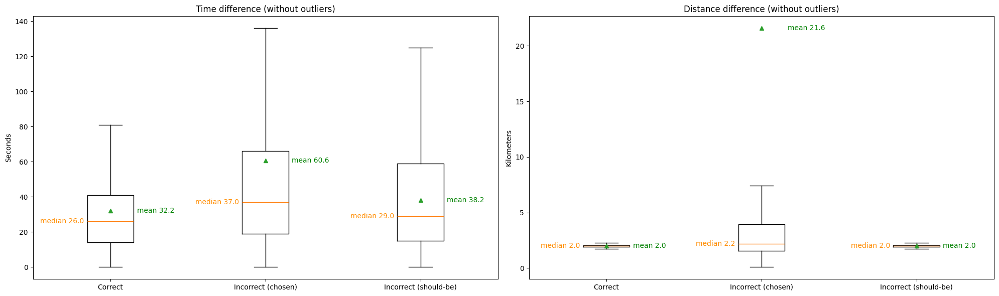

In [58]:
boxplot_time_dist_diff(df_correct_exp, df_incorrect_chosen_exp, df_incorrect_shouldbe_exp)

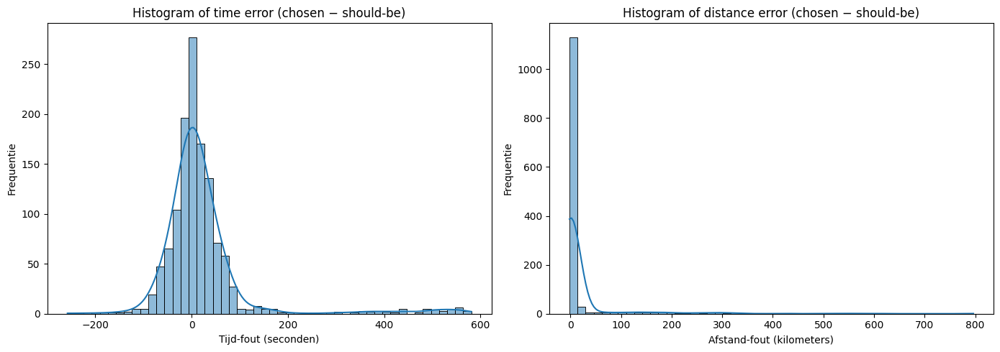

In [59]:
histplot_time_dist_error(df_incorrect_chosen_exp, df_incorrect_shouldbe_exp)

#### __Experiment 2__

In [60]:
df_correct_stats_exp = compute_mean_intra_time(df_correct_exp, df_AIS_stats)
df_incorrect_chosen_stats_exp = compute_mean_intra_time(df_incorrect_chosen_exp, df_AIS_stats)
df_incorrect_shouldbe_stats_exp = compute_mean_intra_time(df_incorrect_shouldbe_exp, df_AIS_stats)

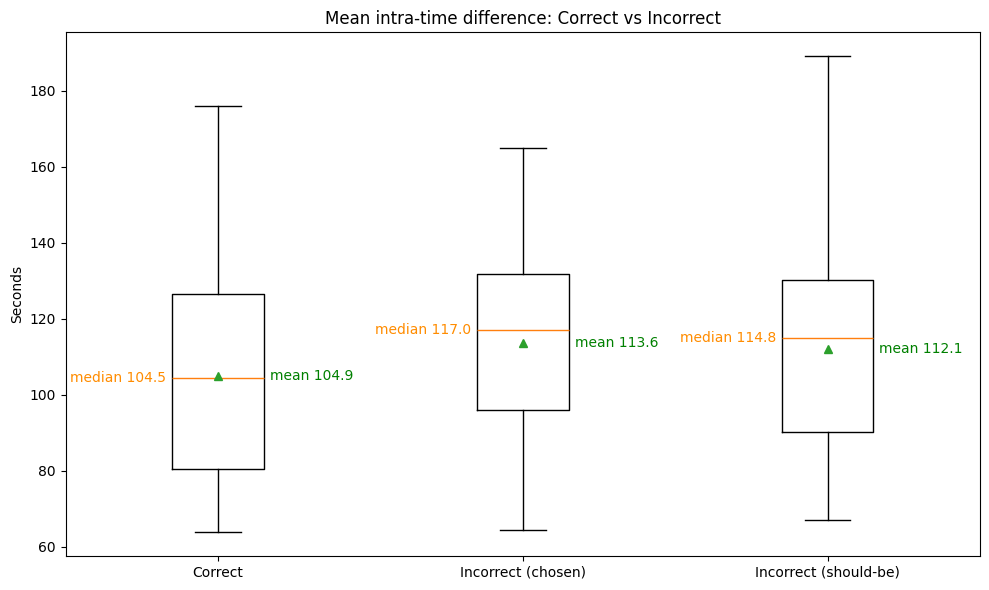

In [61]:
boxplot_mean_intra_time(df_correct_stats_exp, df_incorrect_chosen_stats_exp, df_incorrect_shouldbe_stats_exp)

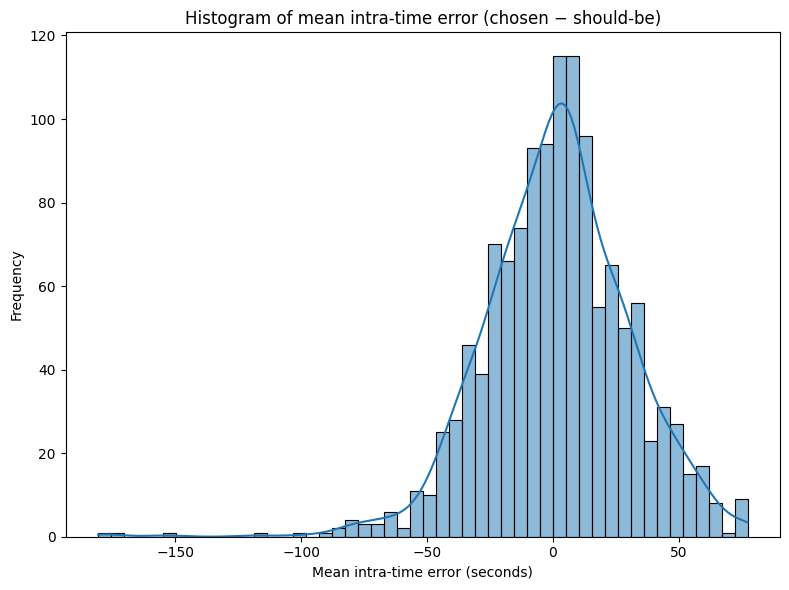

In [62]:
histplot_intra_time_error(df_incorrect_chosen_stats_exp, df_incorrect_shouldbe_stats_exp)

In [89]:
df_AIS["speed_kph"] < 5

0          False
1          False
2          False
3          False
4          False
           ...  
4356540    False
4356541    False
4356542    False
4356543    False
4356544    False
Name: speed_kph, Length: 2164597, dtype: bool

#### __Experiment 3__

In [63]:
df_correct_behavior_exp = compute_track_behavior(df_correct_exp, df_AIS)
df_incorrect_chosen_behavior_exp = compute_track_behavior(df_incorrect_chosen_exp, df_AIS)
df_incorrect_shouldbe_behavior_exp = compute_track_behavior(df_incorrect_shouldbe_exp, df_AIS)

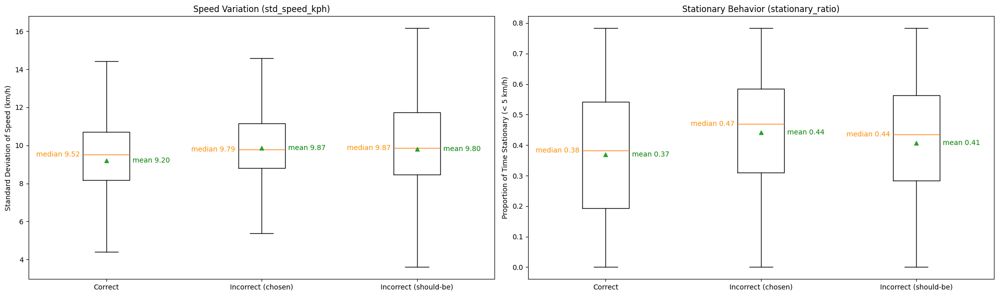

In [64]:
boxplot_track_behavior(df_correct_behavior_exp, df_incorrect_chosen_behavior_exp, df_incorrect_shouldbe_behavior_exp)

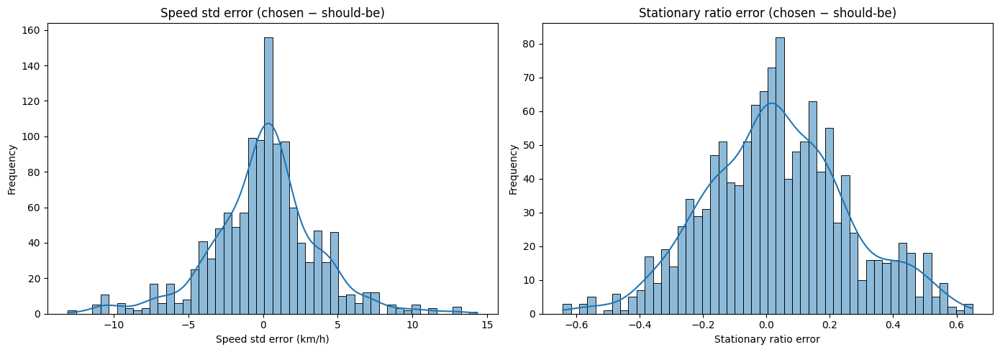

In [65]:
histplot_track_behavior_errors(df_incorrect_chosen_behavior_exp, df_incorrect_shouldbe_behavior_exp)

#### __Experiment 4__

In [66]:
df_correct_track_exp = compute_track_length(df_correct_exp, df_AIS_stats)
df_incorrect_chosen_track_exp = compute_track_length(df_incorrect_chosen_exp, df_AIS_stats)
df_incorrect_shouldbe_track_exp = compute_track_length(df_incorrect_shouldbe_exp, df_AIS_stats)

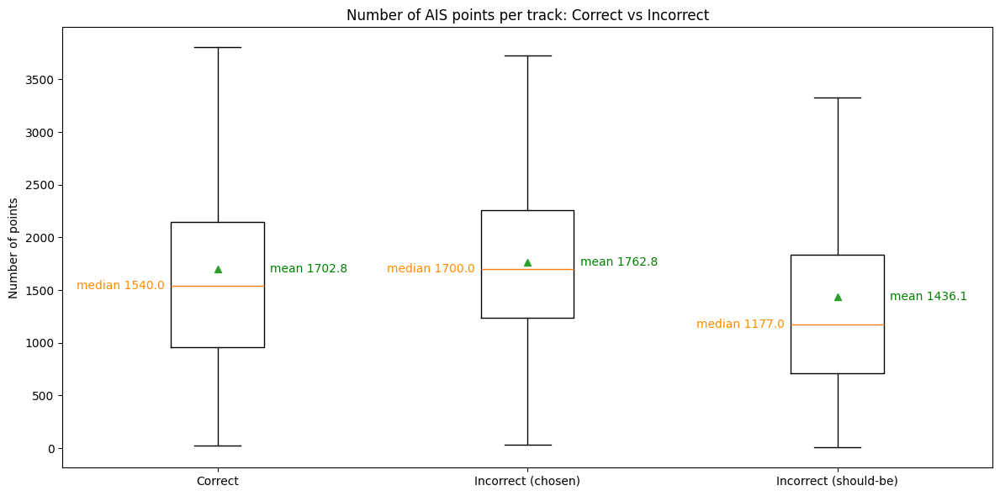

In [67]:
boxplot_track_length(df_correct_track_exp, df_incorrect_chosen_track_exp, df_incorrect_shouldbe_track_exp)

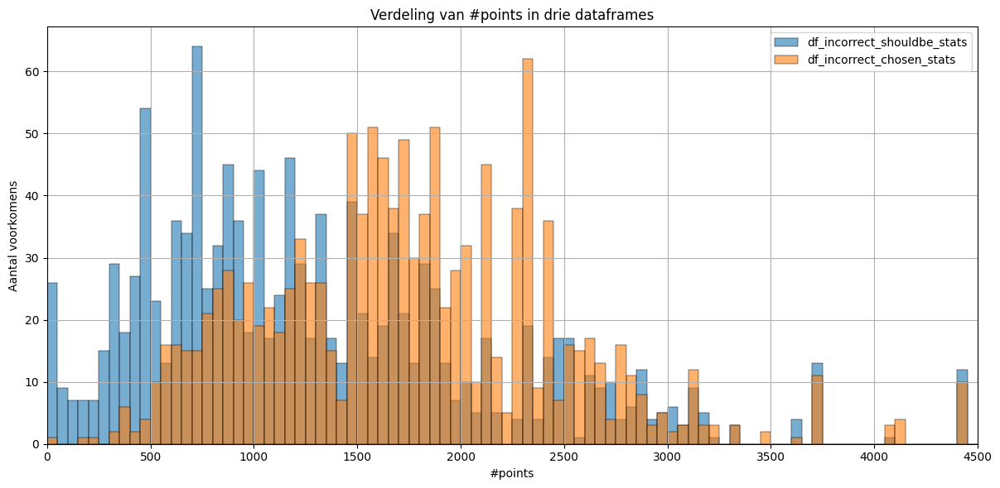

In [68]:
bins = range(0, 9100, 50)  # elke 300 punten, tot 9000

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_shouldbe_track_exp['#points'], bins=bins, alpha=0.6, label='df_incorrect_shouldbe_stats')
sns.histplot(df_incorrect_chosen_track_exp['#points'], bins=bins, alpha=0.6, label='df_incorrect_chosen_stats')

plt.xlabel('#points')
plt.ylabel('Aantal voorkomens')
plt.title('Verdeling van #points in drie dataframes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


In [69]:
df_incorrect_chosen_track_exp

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,#points
0,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:06,"[29.68078, -95.00172]",31.0,3.059381,"(351567000, 19)",1074
1,1,"(215228000, 7)","(636017316, 12)",False,-36.088777,-0.030819,-0.062470,False,2024-01-07 23:08:37,"[29.914754047068236, -89.92648390302227]",2024-01-07 23:09:31,"[29.92402, -89.93593]",54.0,1.374904,"(636017316, 12)",1171
2,1,"(215765000, 2)","(636019582, 6)",False,-49.635657,-0.029197,-0.061431,False,2024-01-06 23:08:37,"[32.12106611689638, -81.15894316353246]",2024-01-06 23:08:14,"[32.13178, -81.14125]",23.0,2.048241,"(636019582, 6)",1700
3,1,"(235058697, 2)","(244730000, 5)",False,-164.895255,-0.052733,-0.117922,False,2024-01-03 15:27:16,"[32.9137754546784, -77.36400195198397]",2024-01-03 15:27:27,"[33.82739, -76.29068]",11.0,142.317248,"(244730000, 5)",3127
4,1,"(241821000, 16)","(566846000, 47)",False,-27.831888,-0.035186,-0.068578,False,2024-01-25 19:11:03,"[28.360325350882313, -89.13041076813573]",2024-01-25 19:11:21,"[28.31621, -89.12095]",18.0,4.992031,"(566846000, 47)",791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1260,35,"(366938780, 0)","(367050160, 2)",False,-76.026994,-0.028400,-0.062529,False,2024-01-05 23:08:37,"[41.91018434588746, -83.0414821255144]",2024-01-05 23:08:17,"[41.90857, -83.05122]",20.0,0.825577,"(367050160, 2)",2677
1261,36,"(309253000, 5)","(477648800, 15)",False,-56.577266,-0.029606,-0.063024,False,2024-01-06 05:08:47,"[40.64369974244571, -74.10709814723222]",2024-01-06 05:09:03,"[40.66081, -74.1527]",16.0,4.291785,"(477648800, 15)",1911
1262,36,"(366904890, 0)","(366906610, 2)",False,-87.806598,-0.028306,-0.063248,False,2024-01-06 02:07:00,"[46.05623173217264, -84.02633062256463]",2024-01-06 02:06:44,"[46.04475, -83.9436]",16.0,6.510895,"(366906610, 2)",3102
1263,37,"(366904890, 0)","(366906610, 2)",False,-86.653297,-0.027935,-0.062418,False,2024-01-06 05:08:47,"[45.576834923822815, -83.48449176468893]",2024-01-06 05:08:14,"[45.58792, -83.48233]",33.0,1.244034,"(366906610, 2)",3102


In [70]:
df_incorrect_chosen_tracks

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,forward_score,normalized_forward_score,normalized_forward_score_alpha,is_true_match_y,RF_Timestamp,RF,AIS_Timestamp,AIS,time_diff,distance_diff,ID,#points
0,1,"(209087000, 10)","(351567000, 19)",False,-33.812336,-0.031483,-0.063266,False,2024-01-07 23:08:37,"[29.677950233611714, -94.97021974531077]",2024-01-07 23:08:06,"[29.68078, -95.00172]",31.0,3.059381,"(351567000, 19)",1074
1,1,"(210499000, 15)","(368270390, 0)",False,-129.600350,-0.029268,-0.067767,False,2024-01-05 08:26:02,"[29.329288852563735, -94.57824815230478]",2024-01-05 08:26:37,"[29.31442, -94.79626]",35.0,21.200605,"(368270390, 0)",4428
2,1,"(215228000, 7)","(636017316, 12)",False,-36.088777,-0.030819,-0.062470,False,2024-01-07 23:08:37,"[29.914754047068236, -89.92648390302227]",2024-01-07 23:09:31,"[29.92402, -89.93593]",54.0,1.374904,"(636017316, 12)",1171
3,1,"(215765000, 2)","(636019582, 6)",False,-49.635657,-0.029197,-0.061431,False,2024-01-06 23:08:37,"[32.12106611689638, -81.15894316353246]",2024-01-06 23:08:14,"[32.13178, -81.14125]",23.0,2.048241,"(636019582, 6)",1700
4,1,"(235010180, 19)","(477909100, 31)",False,-27.637260,-0.035342,-0.068803,False,2024-01-22 23:08:37,"[29.930627608270555, -90.20106819668398]",2024-01-22 23:08:07,"[29.94215, -90.16882]",30.0,3.361191,"(477909100, 31)",782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1695,22,"(366904910, 0)","(366904890, 0)",False,-177.257904,-0.026748,-0.064479,False,2024-01-04 02:07:00,"[45.45138970553554, -83.37123039518876]",2024-01-04 02:07:00,"[45.39452, -83.37871]",0.0,6.350517,"(366904890, 0)",6627
1696,22,"(636018910, 0)","(373765000, 12)",False,-75.801942,-0.028064,-0.061846,False,2024-01-04 02:07:00,"[29.96965953769862, -90.28108684063935]",2024-01-04 02:07:19,"[29.95919, -90.29781]",19.0,1.987593,"(373765000, 12)",2701
1697,23,"(636022464, 30)","(256524000, 97)",False,-70.208690,-0.027938,-0.061125,False,2024-01-26 11:40:10,"[38.950778343375596, -76.41469813659661]",2024-01-26 11:39:07,"[38.95074, -76.41838]",63.0,0.318417,"(256524000, 97)",2513
1698,24,"(256524000, 97)","(636022464, 30)",False,-67.385209,-0.027868,-0.060737,False,2024-01-26 15:27:16,"[38.96300949474396, -76.41017314589891]",2024-01-26 15:26:50,"[38.96507, -76.40624]",26.0,0.410039,"(636022464, 30)",2418


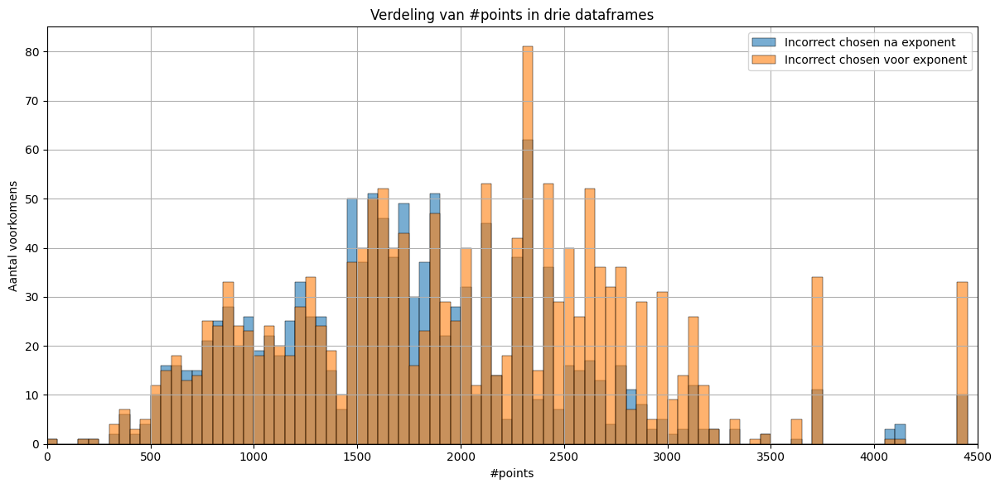

In [71]:
bins = range(0, 9100, 50)  # elke 300 punten, tot 9000

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_chosen_track_exp['#points'], bins=bins, alpha=0.6, label='Incorrect chosen na exponent')
sns.histplot(df_incorrect_chosen_tracks['#points'], bins=bins, alpha=0.6, label='Incorrect chosen voor exponent')

plt.xlabel('#points')
plt.ylabel('Aantal voorkomens')
plt.title('Verdeling van #points in drie dataframes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()


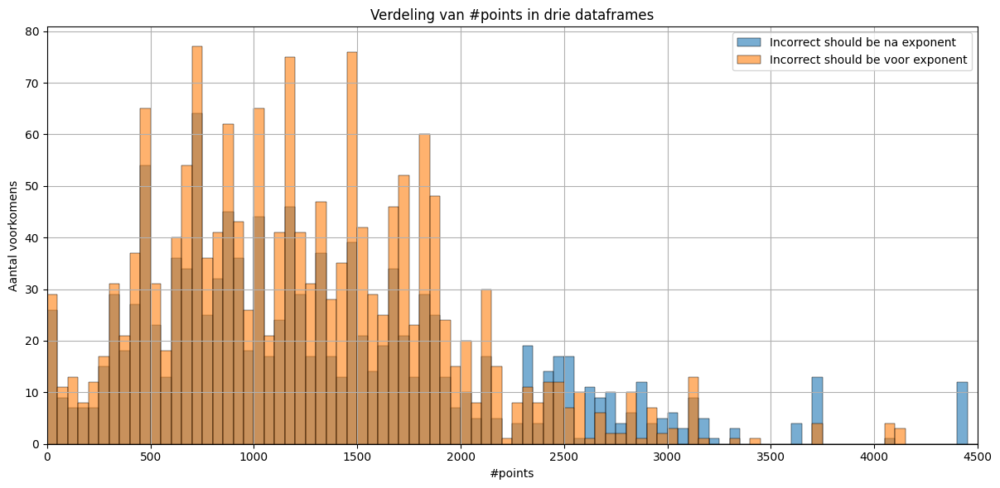

In [72]:
bins = range(0, 9100, 50)  # elke 300 punten, tot 9000

plt.figure(figsize=(12, 6))
sns.histplot(df_incorrect_shouldbe_track_exp['#points'], bins=bins, alpha=0.6, label='Incorrect should be na exponent')
sns.histplot(df_incorrect_shouldbe_tracks['#points'], bins=bins, alpha=0.6, label='Incorrect should be voor exponent')

plt.xlabel('#points')
plt.ylabel('Aantal voorkomens')
plt.title('Verdeling van #points in drie dataframes')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(0,4500)
plt.show()

In [73]:
# df_correct_stats_exp = compute_sampling_rate(df_correct_exp, df_AIS_stats)
# df_incorrect_chosen_stats_exp = compute_sampling_rate(df_incorrect_chosen_exp, df_AIS_stats)
# df_incorrect_shouldbe_stats_exp = compute_sampling_rate(df_incorrect_shouldbe_exp, df_AIS_stats)

In [74]:
# boxplot_sampling_rate(df_correct_stats_exp, df_incorrect_chosen_stats_exp, df_incorrect_shouldbe_stats_exp)

Voorbeeld die verkeerd gematcht is Rf signaal 1 van mmsi, track id (209087000, 10) met mmsi, track id (351567000, 19):	
- chosen: 
    - time diff: 31.0
    - dist diff: 3.059381
    - AIS naar RF trans prob: 0.3728
    - intra: 112.872321
    - speed variation:
    - stationary behavior:
- should be: 
    - time diff: 1.0
    - dist diff: 2.146568
    - AIS naar RF trans prob: 0.5395
    - intra: 134.707915
    - speed variation:
    - stationary behavior:

In [75]:
df_best_norm_exp_0_9

NameError: name 'df_best_norm_exp_0_9' is not defined

In [ ]:
df_best_norm_exp_0_9[df_best_norm_exp_0_9["is_true_match"] == False]

,RF_signal_id,RF_track_id,AIS_track_id,is_true_match,normalized_forward_score_alpha
1,1,"(209087000, 10)","(351567000, 19)",False,-0.063266
17,1,"(215228000, 7)","(636017316, 12)",False,-0.062470
20,1,"(215765000, 2)","(636019582, 6)",False,-0.061431
39,1,"(235058697, 2)","(244730000, 5)",False,-0.117922
47,1,"(241821000, 16)","(566846000, 47)",False,-0.068578
...,...,...,...,...,...
8324,35,"(366938780, 0)","(367050160, 2)",False,-0.062529
8327,36,"(309253000, 5)","(477648800, 15)",False,-0.063024
8329,36,"(366904890, 0)","(366906610, 2)",False,-0.063248
8335,37,"(366904890, 0)","(366906610, 2)",False,-0.062418


In [ ]:
df_train_set[(df_train_set["ID"] == (209087000, 10)) & (~df_train_set["RF"].isna())]

,ID,track_id,MMSI,Timestamp,AIS_Timestamp,RF_Timestamp,AIS,RF,State
1366,"(209087000, 10)",10,209087000,2024-01-07 23:08:37,NaT,2024-01-07 23:08:37,None,"[29.677950233611714, -94.97021974531077]",RF
1367,"(209087000, 10)",10,209087000,2024-01-08 02:05:36,2024-01-08 02:05:36,2024-01-08 02:07:00,"[29.68232, -94.99202]","[29.6875718287059, -94.97246318967987]",M
1368,"(209087000, 10)",10,209087000,2024-01-08 05:08:47,NaT,2024-01-08 05:08:47,None,"[29.69715677184802, -94.98026919798889]",RF
1369,"(209087000, 10)",10,209087000,2024-01-08 08:26:02,NaT,2024-01-08 08:26:02,None,"[29.685405504836147, -94.97315807158326]",RF
1370,"(209087000, 10)",10,209087000,2024-01-08 11:38:43,2024-01-08 11:38:43,2024-01-08 11:40:10,"[29.68232, -94.99205]","[29.698288153117197, -94.98381659136895]",M
1371,"(209087000, 10)",10,209087000,2024-01-08 15:27:16,NaT,2024-01-08 15:27:16,None,"[29.67097798146197, -94.97595046395112]",RF
1372,"(209087000, 10)",10,209087000,2024-01-08 19:11:03,NaT,2024-01-08 19:11:03,None,"[29.692802884641708, -94.97657186309652]",RF
1373,"(209087000, 10)",10,209087000,2024-01-08 23:08:37,NaT,2024-01-08 23:08:37,None,"[29.527361794154785, -94.89923303940037]",RF
1374,"(209087000, 10)",10,209087000,2024-01-09 02:07:00,NaT,2024-01-09 02:07:00,None,"[29.17842022816227, -94.47768029245181]",RF
1375,"(209087000, 10)",10,209087000,2024-01-09 05:08:47,NaT,2024-01-09 05:08:47,None,"[28.723601852510424, -93.71638574082982]",RF


In [ ]:
plot_AIS_and_RF_data(df_AIS, df_train_set, [(209087000, 10), (351567000, 19)]) # kleur punten anders en zoek afstand en tijd voor beide op 